In [1]:
import pandas as pd

In [2]:
# Load the file
file_path = r"..\Current-macroeconomic-situation-Tables-Based-on-Six-Month-data-of-2082.83.xlsx"

# Sheet name
sheet_name = "32&33.Exchange Rate"

df = pd.read_excel(
    file_path,
    sheet_name=sheet_name,
    skiprows=3,           # skip the first 3 rows (title and headers)
    header=0              # first row after skip becomes column names
)

#Assign better column names manually
columns = [
    'skip0', 'Fiscal_Year', 'Month',              # A B C
    'Buying_End', 'Selling_End', 'Middle_End',    # D E F   ← Month End*
    'Buying_Avg', 'Selling_Avg', 'Middle_Avg',    # G H I   ← Monthly Average*
    'skip1', 'skip2', 'skip3', 'skip4', 'skip5'   # leftover junk
]

df.columns = columns

# Drop completely useless columns
df = df.drop(columns=[c for c in df.columns if c.startswith('skip')]).copy()

# Forward-fill Fiscal Year  (fill missing values in 'Fiscal_Year' column)
df['Fiscal_Year'] = df['Fiscal_Year'].ffill()

# drop all rows after any empty 'Month' (after the last valid month)
# find first empty Month row
empty_index = df[df['Month'].isna()].index
if len(empty_index) > 0:
    df = df.loc[:empty_index[0] - 1]
    
print("\nFirst 5 rows:\n", df.head(5))



First 5 rows:
   Fiscal_Year      Month  Buying_End  Selling_End Middle_End  Buying_Avg  \
0     2011/12     August       72.10        72.70       72.4   71.107187   
1     2011/12  September       75.60        76.20       75.9   73.617097   
2     2011/12    October       78.10        78.70       78.4   77.854667   
3     2011/12   November       80.74        81.34      81.04   78.983333   
4     2011/12   December       85.51        86.11      85.81   82.697241   

  Selling_Avg Middle_Avg  
0   71.707188  71.407188  
1   74.217097  73.917097  
2   78.454667  78.154667  
3   79.583333  79.283333  
4   83.297241  82.997241  


In [3]:
#Identify annual average rows
annual_mask = df['Month'].astype(str).str.contains('annual|average', case=False, na=False)

df_annual = df[annual_mask].copy().reset_index(drop=True)
df_monthly = df[~annual_mask].copy().reset_index(drop=True)

# Keep only the most reliable column for annual trend (Monthly Average Middle)
df_annual = df_annual[['Fiscal_Year', 'Middle_Avg']].dropna(subset=['Middle_Avg'])
df_annual = df_annual.rename(columns={'Middle_Avg': 'Exchange_Rate_NRs_USD'})
df_annual['Exchange_Rate_NRs_USD'] = pd.to_numeric(df_annual['Exchange_Rate_NRs_USD'], errors='coerce')
df_annual = df_annual.dropna().reset_index(drop=True)

# ────────────────────────────────────────────────
# Step 5: Clean monthly frame (convert to numeric)
for col in ['Buying_End', 'Selling_End', 'Middle_End',
            'Buying_Avg', 'Selling_Avg', 'Middle_Avg']:
    df_monthly[col] = pd.to_numeric(df_monthly[col], errors='coerce')

# # Optional: create combined "Month-Year" for better plotting if needed
# df_monthly['Month_Year'] = df_monthly['Fiscal_Year'] + " " + df_monthly['Month']

print("\nANNUAL AVERAGES:")
print(df_annual.round(2))

print("\nFIRST 10 MONTHLY ROWS:")
print(df_monthly[['Fiscal_Year', 'Month', 'Middle_End', 'Middle_Avg']].head(11).round(2))


ANNUAL AVERAGES:
   Fiscal_Year  Exchange_Rate_NRs_USD
0      2011/12                  81.02
1      2012/13                  87.96
2      2013/14                  98.25
3      2014/15                  99.49
4      2015/16                 106.35
5      2016/17                 106.21
6      2017/18                 104.37
7      2018/19                 112.88
8      2019/20                 116.31
9      2020/21                 117.87
10     2021/22                 120.84
11     2022/23                 130.75
12     2023/24                 133.03
13     2024/25                 136.29

FIRST 10 MONTHLY ROWS:
   Fiscal_Year      Month  Middle_End  Middle_Avg
0      2011/12     August       72.40       71.41
1      2011/12  September       75.90       73.92
2      2011/12    October       78.40       78.15
3      2011/12   November       81.04       79.28
4      2011/12   December       85.81       83.00
5      2011/12    January       82.20       84.46
6      2011/12   February       79.35 

### Long-Term Trend – Annual Average Rate:

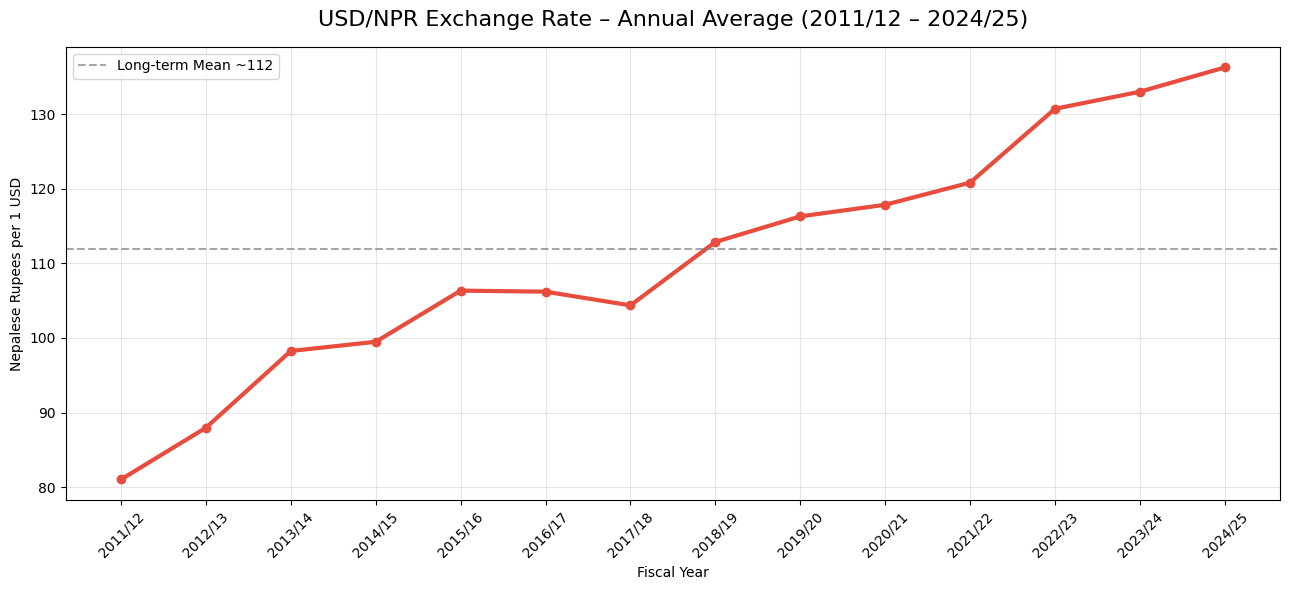

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(13, 6))
plt.plot(df_annual['Fiscal_Year'], df_annual['Exchange_Rate_NRs_USD'],
         marker='o', linewidth=3, color='#e74c3c', markersize=6)
plt.title('USD/NPR Exchange Rate – Annual Average (2011/12 – 2024/25)', fontsize=16, pad=15)
plt.ylabel('Nepalese Rupees per 1 USD')
plt.xlabel('Fiscal Year')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.axhline(112, color='gray', linestyle='--', alpha=0.7, label='Long-term Mean ~112')
plt.legend()
plt.tight_layout()
plt.show()

Steady depreciation with clear structural break post-2019/20. Average annual rate of change ≈ 4.8% over the full period.

### Correlation Between Month-End vs Monthly Average Rates:

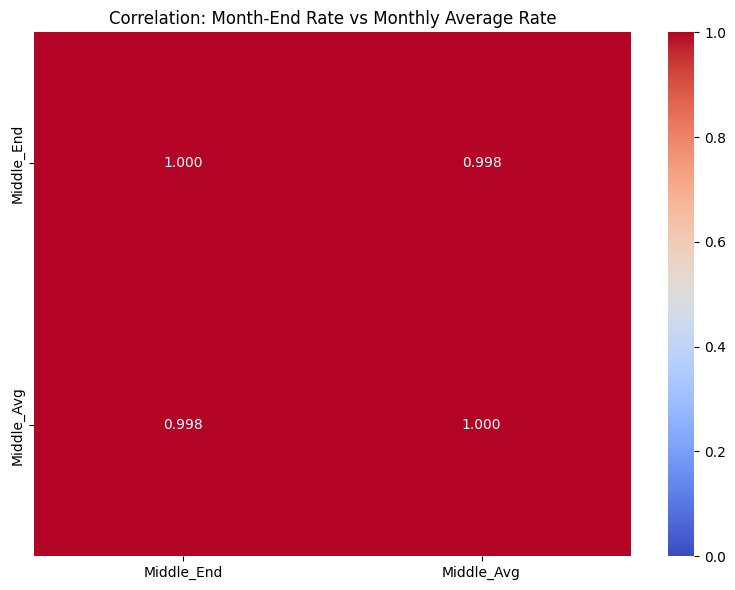

In [5]:
corr_matrix = df_monthly[['Middle_End', 'Middle_Avg']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt='.3f')
plt.title('Correlation: Month-End Rate vs Monthly Average Rate')
plt.tight_layout()
plt.show()

Extremely high correlation (~0.999) – both measures move almost identically

### Cumulative Impact Area Chart:

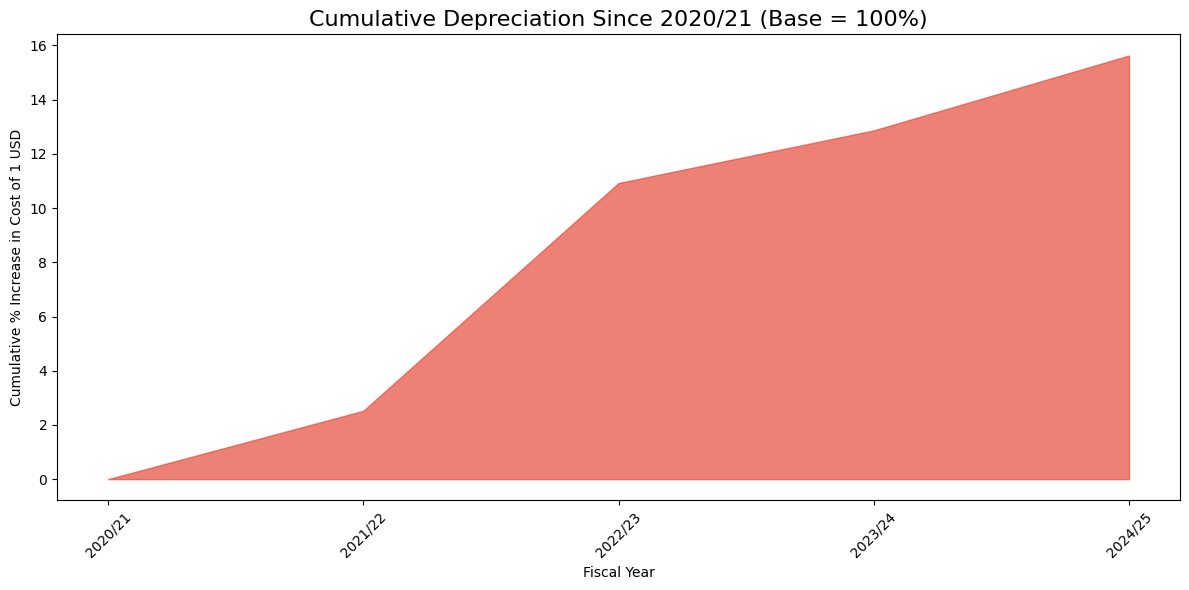

In [6]:
recent = df_annual[df_annual['Fiscal_Year'] >= '2020/21'].copy()
recent['Cumulative_Dep_%'] = (recent['Exchange_Rate_NRs_USD'] / recent.iloc[0]['Exchange_Rate_NRs_USD'] - 1) * 100

plt.figure(figsize=(12, 6))
plt.fill_between(recent['Fiscal_Year'], 0, recent['Cumulative_Dep_%'], color='#e74c3c', alpha=0.7)
plt.title('Cumulative Depreciation Since 2020/21 (Base = 100%)', fontsize=16)
plt.ylabel('Cumulative % Increase in Cost of 1 USD')
plt.xlabel('Fiscal Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Since 2020/21, the effective cost of one USD has risen 15–18% cumulatively — a direct hit on Nepal’s import-dependent economy.

### Smoothed Trend – 12-Month Rolling Average:

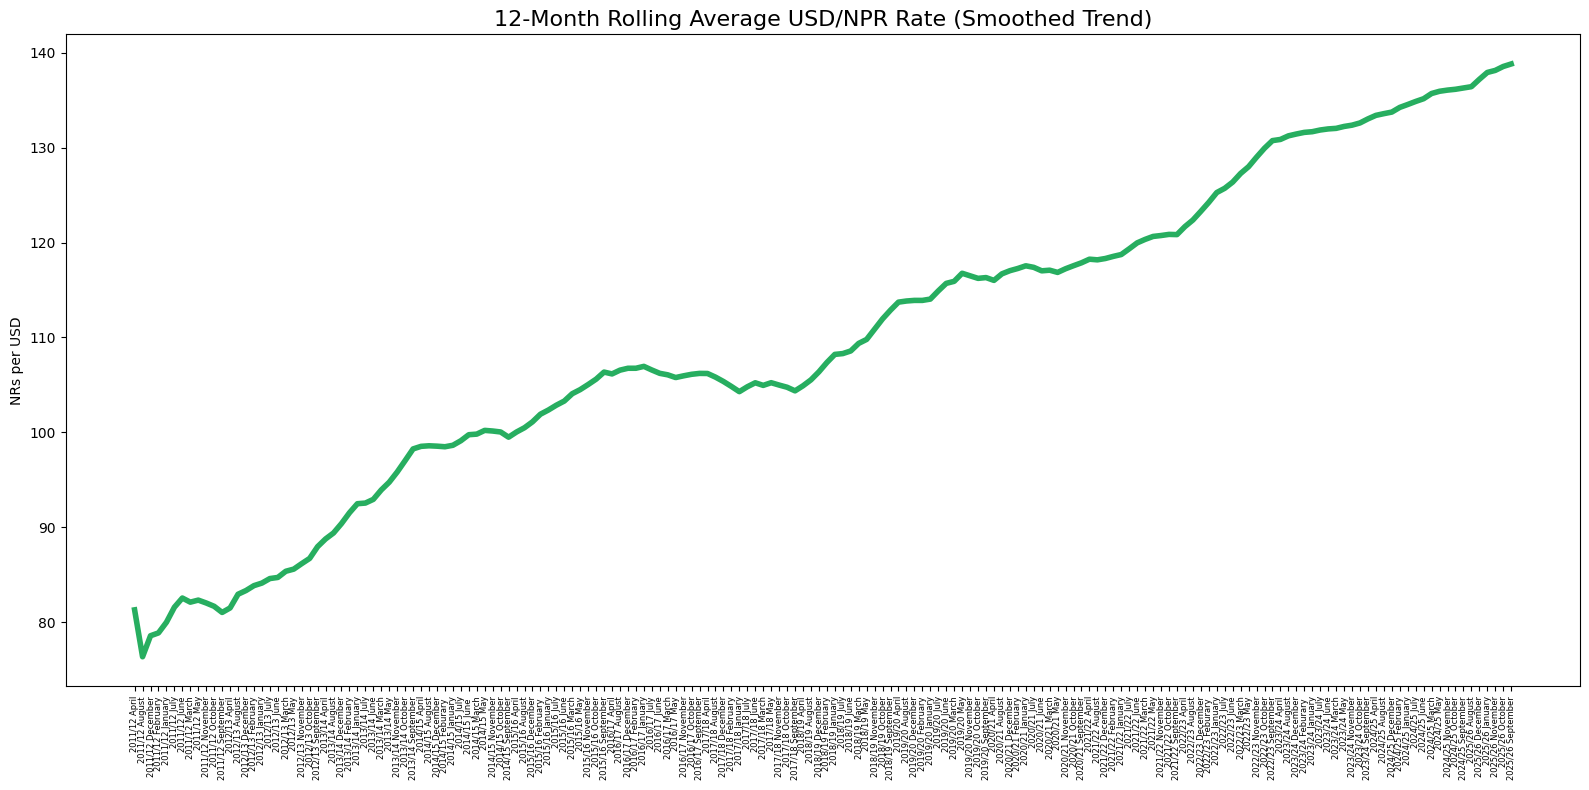

In [7]:
df_monthly = df_monthly.sort_values(['Fiscal_Year', 'Month'])  # ensure chronological order
df_monthly['Rolling_12m_Avg'] = df_monthly['Middle_Avg'].rolling(window=12, min_periods=1).mean()

plt.figure(figsize=(16, 8))
plt.plot(df_monthly['Fiscal_Year'] + " " + df_monthly['Month'], 
         df_monthly['Rolling_12m_Avg'], color='#27ae60', linewidth=4)
plt.title('12-Month Rolling Average USD/NPR Rate (Smoothed Trend)', fontsize=16)
plt.ylabel('NRs per USD')
#fontsize for x-axis labels
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

The rolling average confirms acceleration after mid-2020 and shows no signs of reversal in 2024/25–2025/26.